In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [37]:
#load folder 1
folder = Path("msystems/ZGNR_20_L120_p0.02_n100_20260330_063507")  # change for diff folders 

# one configuration file tranport 
file = folder / "conf_0001_transport_results.npz"
data = np.load(file)
# one configuration file structure
structure = folder / "conf_0001_structure_data.npz"
strucdata = np.load(structure, allow_pickle=True)

print(strucdata.files)

# print( data.files) #whats inside 

['conf_id', 'z_index', 'd_length', 'buffer', 'sweeps', 'P0', 'syscoords', 'syssubs', 'sysedges', 'pred_mom', 'trans_ind', 'x1', 'y1', 'subs1', 'onsites', 'onsites_up', 'onsites_down', 'h_dev', 'cells', 'dev_sites_l', 'dev_sites_r', 'llead_ind', 'rlead_ind', 'vdevl_lead', 'vdevr_lead', 't_vacs', 'b_vacs', 'tot_vacs']


In [53]:
print(x1.shape)
print(m.shape)

(5323,)
(6121,)


In [35]:

# print(data["energies"][:10])
# print(data["transmission"][:10])
print(data["conf_id"])
print(data.files)

1
['conf_id', 'energies', 'trans', 'trans_up', 'trans_down', 'z_index', 'd_length', 'buffer', 'sweeps', 'P0']


In [10]:
#for nm
# energies = data["energies"]
# transmission = data["transmission"]

es = data['energies']
trans = data['trans']
trans_up = data['trans_up']
trans_down = data['trans_down']

#for nm
# print( energies.shape)
# print(transmission.shape) # not the same  y- i returned trans and es in piple so saved twice basically 
print(es.shape)
print(trans.shape)

(201,)
(201,)


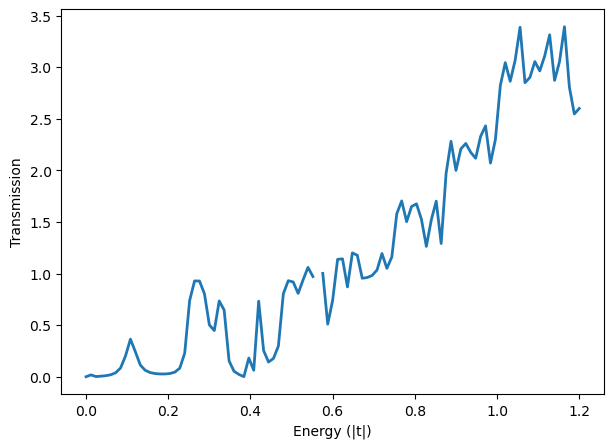

In [52]:
#plot one configuration 

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(energies, transmission[0], lw=2) # just printied the first colunm dik what the 2 is check script 
ax.set_xlabel("Energy (|t|)")
ax.set_ylabel("Transmission")
# ax.set_title(f"Transmission – conf {conf_id}")

# ax.grid(True, alpha=0.3)
plt.show()


In [30]:
print(transmission) # why is there a nan ,neeed to remove for averaging 

[[4.23107579e-04 1.80257338e-02 1.97647729e-03 5.66638095e-03
  1.02861771e-02 1.92200406e-02 3.87563665e-02 8.53092327e-02
  2.02273552e-01 3.64456038e-01 2.41951272e-01 1.13720316e-01
  6.22289758e-02 4.07634270e-02 3.10999295e-02 2.71562269e-02
  2.71082773e-02 3.15213834e-02 4.46575662e-02 8.34949639e-02
  2.28476095e-01 7.38163973e-01 9.28736618e-01 9.27913323e-01
  8.05664674e-01 5.02589653e-01 4.47734959e-01 7.34607288e-01
  6.46270386e-01 1.53472537e-01 5.35151311e-02 2.23676950e-02
  1.11667489e-03 1.81325419e-01 6.30895431e-02 7.32500848e-01
  2.53864867e-01 1.42641477e-01 1.77715766e-01 2.98204055e-01
  8.03969774e-01 9.31025917e-01 9.18516830e-01 8.07753718e-01
  9.38085086e-01 1.05999368e+00 9.71025094e-01            nan
  1.00171509e+00 5.09637735e-01 7.41289629e-01 1.13740932e+00
  1.14285243e+00 8.70787465e-01 1.20036180e+00 1.17728745e+00
  9.54584101e-01 9.61633825e-01 9.81170704e-01 1.03482520e+00
  1.19427052e+00 1.05060984e+00 1.16111011e+00 1.57914647e+00
  1.7038

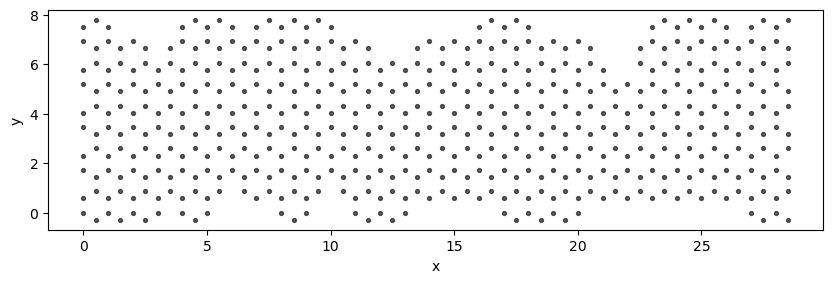

In [50]:
coords = strucdata["a"]   # atomic coordinates

fig, ax = plt.subplots(figsize=(10, 3))

ax.scatter(coords[:, 0], coords[:, 1], s=8, c="k", alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")

plt.show()

### **Loading all files in folder with same parameters** 

In [61]:
all_files = sorted(folder.glob("conf_*_transport_results.npz"))

# print(f"Found {len(all_files)} configurations")

Found 5 configurations


In [67]:
all_transmissions = []
energies = None

for f in all_files:
    data = np.load(f)
    
    if energies is None:
        energies = data["energies"]   # same for all configs
    
    all_transmissions.append(data["transmission"])

Transmissions_combined = np.array(all_transmissions)   # shape = (N_configs, N_energies)

print(Transmissions_combined.shape)

(5, 2, 101)


In [71]:
print(Transmissions_combined[0])

[[4.23107579e-04 1.80257338e-02 1.97647729e-03 5.66638095e-03
  1.02861771e-02 1.92200406e-02 3.87563665e-02 8.53092327e-02
  2.02273552e-01 3.64456038e-01 2.41951272e-01 1.13720316e-01
  6.22289758e-02 4.07634270e-02 3.10999295e-02 2.71562269e-02
  2.71082773e-02 3.15213834e-02 4.46575662e-02 8.34949639e-02
  2.28476095e-01 7.38163973e-01 9.28736618e-01 9.27913323e-01
  8.05664674e-01 5.02589653e-01 4.47734959e-01 7.34607288e-01
  6.46270386e-01 1.53472537e-01 5.35151311e-02 2.23676950e-02
  1.11667489e-03 1.81325419e-01 6.30895431e-02 7.32500848e-01
  2.53864867e-01 1.42641477e-01 1.77715766e-01 2.98204055e-01
  8.03969774e-01 9.31025917e-01 9.18516830e-01 8.07753718e-01
  9.38085086e-01 1.05999368e+00 9.71025094e-01            nan
  1.00171509e+00 5.09637735e-01 7.41289629e-01 1.13740932e+00
  1.14285243e+00 8.70787465e-01 1.20036180e+00 1.17728745e+00
  9.54584101e-01 9.61633825e-01 9.81170704e-01 1.03482520e+00
  1.19427052e+00 1.05060984e+00 1.16111011e+00 1.57914647e+00
  1.7038

In [73]:
T_avg = np.nanmean(Transmissions_combined, axis=0)

/var/folders/mv/g7t2t7zs6zjdv1hksbybwd500000gn/T/ipykernel_27147/1007442215.py:1: RuntimeWarning: Mean of empty slice
  T_avg = np.nanmean(Transmissions_combined, axis=0)


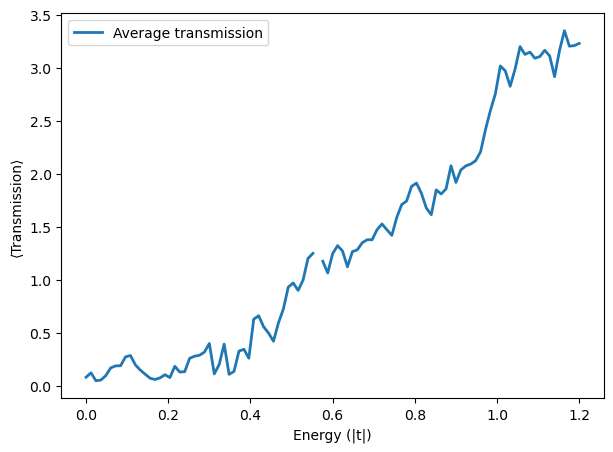

In [81]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(energies, T_avg[0], lw=2, label="Average transmission")


ax.set_xlabel("Energy (|t|)")
ax.set_ylabel("⟨Transmission⟩")
ax.legend()


plt.show()

In [125]:
folder2 = Path("systems/ZGNR_10_L25_p0.01_n25_20260206_113149")  # change for diff folders 
all_files2 = sorted(folder2.glob("conf_*_transport_results.npz"))
print(f"Found {len(all_files2)} configurations")

Found 25 configurations


In [127]:
all_transmissions2 = []
energies = None

for f in all_files2:
    data = np.load(f)
    
    if energies is None:
        energies = data["energies"]   # same for all configs
    
    all_transmissions2.append(data["transmission"])

Transmissions_combined2 = np.array(all_transmissions2)   # shape = (N_configs, N_energies)

# print(Transmissions_combined2.shape)

In [129]:
T_avg2 = np.nanmean(Transmissions_combined, axis=0)


/var/folders/mv/g7t2t7zs6zjdv1hksbybwd500000gn/T/ipykernel_27147/3971975371.py:1: RuntimeWarning: Mean of empty slice
  T_avg2 = np.nanmean(Transmissions_combined, axis=0)


ValueError: x and y must have same first dimension, but have shapes (101,) and (2, 101)

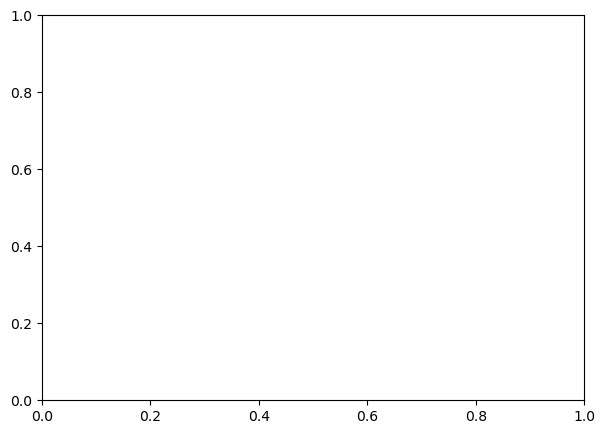

In [165]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(energies, T_avg2[0], lw=2, label="Average transmission")

ax.set_xlabel("Energy (|t|)")
ax.set_ylabel("⟨Transmission⟩")
ax.legend()


plt.show()

In [133]:
#load folder 1
folder50 = Path("systems/ZGNR_20_L30_p0.5_n25_20260207_221138")  # change for diff folders 

# one configuration file tranport 
file50 = folder50 / "conf_0001_transport_results.npz"
data50 = np.load(file50)
# one configuration file structure
structure50 = folder50 / "conf_0001_structure_data.npz"
strucdata50 = np.load(structure50, allow_pickle=True)

print(strucdata.files)

# print( data.files) #whats inside 

['a', 'subs', 'dmat', 'cells', 'h_dev', 'h_lead', 'vlr_lead', 'onsites', 'dev_sites_l', 'dev_sites_r', 'llead_ind', 'rlead_ind', 'vdevl_lead', 'vdevr_lead', 'conf_id', 'edge_prob', 'num_etchs', 'disorder_length', 'padding', 'z_index']


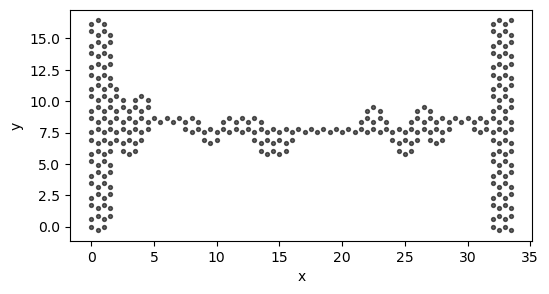

In [135]:
coords50 = strucdata50["a"]   # atomic coordinates

fig, ax = plt.subplots(figsize=(10, 3))

ax.scatter(coords50[:, 0], coords50[:, 1], s=8, c="k", alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")

plt.show()

In [189]:
folder4 = Path("systems/ZGNR_20_L30_p0.01_n25_20260207_213536")  # change for diff folders 
all_files4 = sorted(folder4.glob("conf_*_transport_results.npz"))

config =folder4 / "conf_0050_transport_results.npz"
data_config = np.load(config)
T_config = data_config["transmission"]
print(f"Found {len(all_files4)} configurations")

Found 50 configurations


In [191]:
all_transmissions4 = []
energies = None

for f in all_files4:
    data = np.load(f)
    
    if energies is None:
        energies = data["energies"]   # same for all configs
    
    all_transmissions4.append(data["transmission"])

Transmissions_combined4 = np.array(all_transmissions4)   # shape = (N_configs, N_energies)

print(Transmissions_combined4.shape)
print(energies.shape)

(50, 101)
(101,)


In [193]:
T_avg4 = np.nanmean(Transmissions_combined4, axis=0)

print(T_avg4.shape)

(101,)


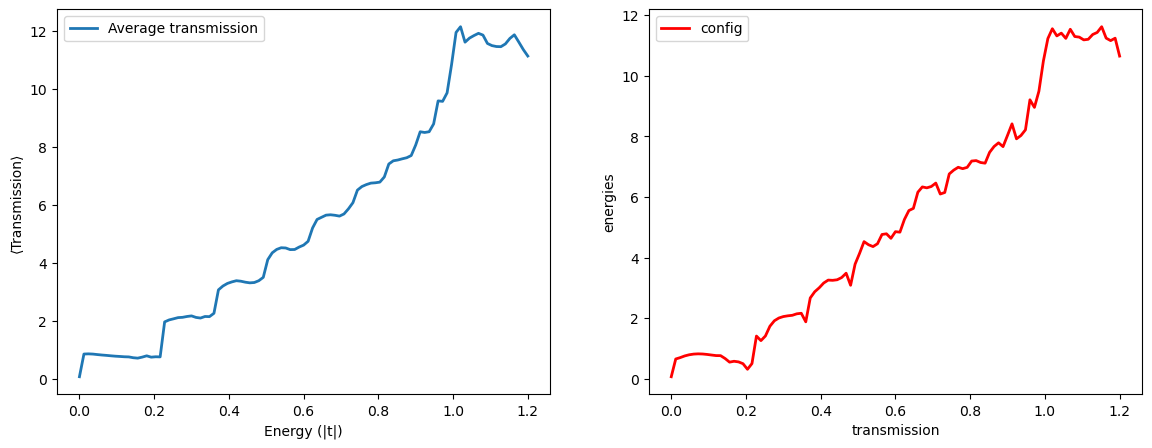

In [197]:
# fig, ax = plt.subplots(figsize=(7, 5))
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(14,5), sharex=True)
                              
ax1.plot(energies, T_avg4, lw=2, label="Average transmission")

ax1.set_xlabel("Energy (|t|)")
ax1.set_ylabel("⟨Transmission⟩")
ax1.legend()

ax2.plot(energies, T_config, color="red", lw=2,label="config")

ax2.set_xlabel("transmission")
ax2.set_ylabel("energies")
ax2.legend()

plt.show()

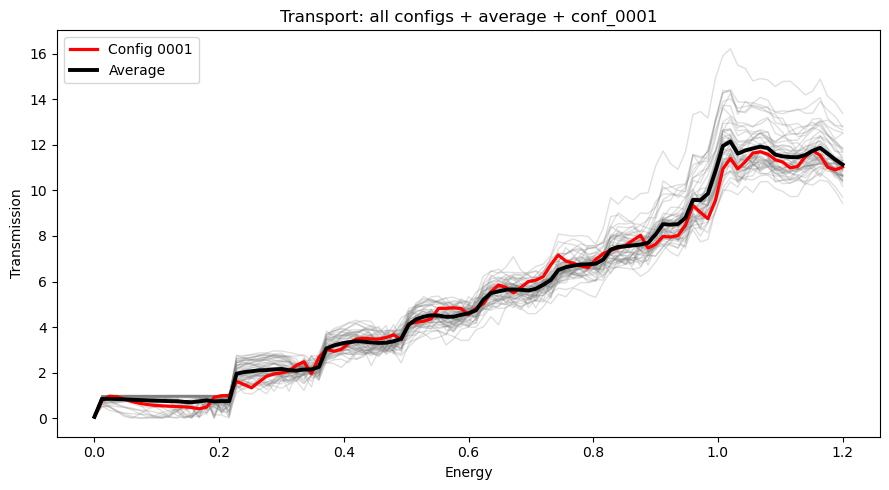

In [167]:

folder = Path("systems/ZGNR_20_L30_p0.01_n25_20260207_213536")

# ---- load all configs ----
all_files4 = sorted(folder.glob("conf_*_transport_results.npz"))

all_transmissions4 = []
energies = None

for f in all_files4:
    data = np.load(f)
    if energies is None:
        energies = data["energies"]        # same for all configs
    all_transmissions4.append(data["transmission"])

Transmissions_combined4 = np.array(all_transmissions4)   # (N_configs, N_energies)

# ---- load config 0001 explicitly ----
file_conf1 = folder / "conf_0001_transport_results.npz"
data1 = np.load(file_conf1)
T_conf1 = data1["transmission"]

# ---- average ----
T_avg = np.nanmean(Transmissions_combined4, axis=0)

# ---- plot ----
plt.figure(figsize=(9,5))

# all configs: grey transparent
for i in range(Transmissions_combined4.shape[0]):
    plt.plot(energies, Transmissions_combined4[i],
             color="grey", alpha=0.25, lw=1)

# config 0001: red
plt.plot(energies, T_conf1,
         color="red", lw=2.3, label="Config 0001")

# average: black
plt.plot(energies, T_avg,
         color="black", lw=2.8, label="Average")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Transport: all configs + average + conf_0001")
plt.legend()
plt.tight_layout()
plt.show()


>***NONMAG***

In [447]:
#load folder 1
folder = Path("msystems/ZGNR_20_L90_p0.02_n100_20260407_190931")  # change for diff folders 
folderp=Path("msystems/ZGNR_20_L90_p0_n0_20260407_185849")

# one configuration file tranport 
file = folder / "conf_0001_transport_results.npz"
data = np.load(file)
# one configuration file structure
structure = folder / "conf_0001_structure_data.npz"
strucdata = np.load(structure, allow_pickle=True)

#prisitne vertion of loaded disorede file 
# one configuration file tranport 
filep = folderp / "conf_0001_transport_results.npz"
datap = np.load(filep)
# one configuration file structure
structurep = folderp / "conf_0001_structure_data.npz"
strucdatap = np.load(structurep, allow_pickle=True)

print(strucdata.files)
print(strucdatap.files)

['conf_id', 'z_index', 'd_length', 'buffer', 'sweeps', 'P0', 'syscoords', 'syssubs', 'sysedges', 'pred_mom', 'trans_ind', 'x1', 'y1', 'subs1', 'onsites', 'onsites_up', 'onsites_down', 'h_dev', 'cells', 'dev_sites_l', 'dev_sites_r', 'llead_ind', 'rlead_ind', 'vdevl_lead', 'vdevr_lead', 't_vacs', 'b_vacs', 'tot_vacs']
['conf_id', 'z_index', 'd_length', 'buffer', 'sweeps', 'P0', 'syscoords', 'syssubs', 'sysedges', 'pred_mom', 'trans_ind', 'x1', 'y1', 'subs1', 'onsites', 'onsites_up', 'onsites_down', 'h_dev', 'cells', 'dev_sites_l', 'dev_sites_r', 'llead_ind', 'rlead_ind', 'vdevl_lead', 'vdevr_lead', 't_vacs', 'b_vacs', 'tot_vacs']


In [449]:
print(datap.files)

['conf_id', 'energies', 'trans', 'trans_up', 'trans_down', 'z_index', 'd_length', 'buffer', 'sweeps', 'P0']


In [491]:
x1 = strucdata["x1"]
y1 = strucdata["y1"]
m=strucdata["pred_mom"]
trans_ind = strucdata["trans_ind"]

m1 = m[trans_ind]
hdev = strucdata["h_dev"]
cells=strucdata["cells"]


###############################
x1p = strucdatap["x1"]
y1p = strucdatap["y1"]
mp=strucdatap["pred_mom"]
trans_indp = strucdatap["trans_ind"]
subsp=strucdatap["subs1"]

m1p = mp[trans_indp]

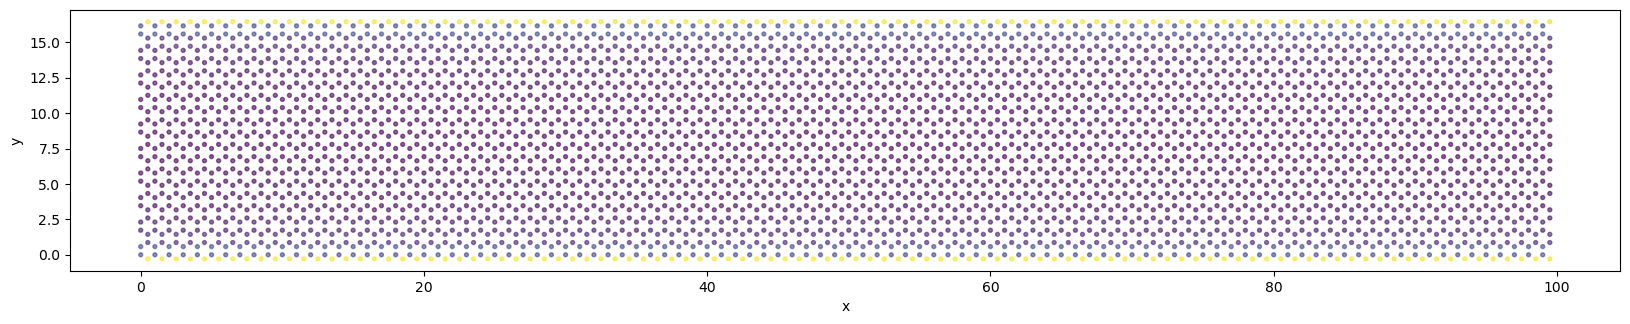

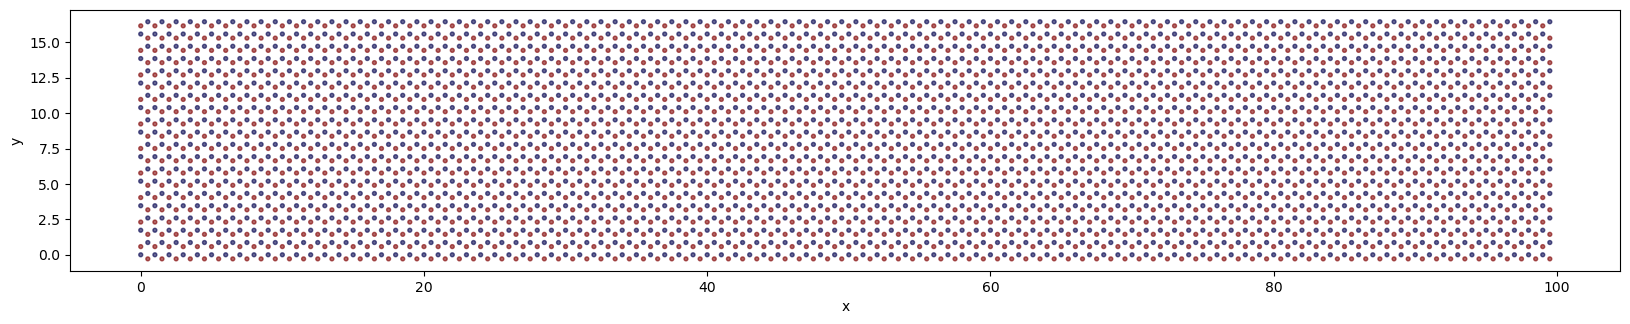

In [453]:

fig, ax = plt.subplots(figsize=(20, 15))

ax.scatter(x1p, y1p, s=8,c=abs(m1p), cmap="viridis" ,alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")

plt.show()

fig, ax = plt.subplots(figsize=(20, 15))

ax.scatter(x1p, y1p, s=8,c=subsp,cmap="seismic" ,alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")

plt.show()

/var/folders/mv/g7t2t7zs6zjdv1hksbybwd500000gn/T/ipykernel_9080/3343391889.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x1, y1, s=8, cmap="viridis" ,alpha=0.6)


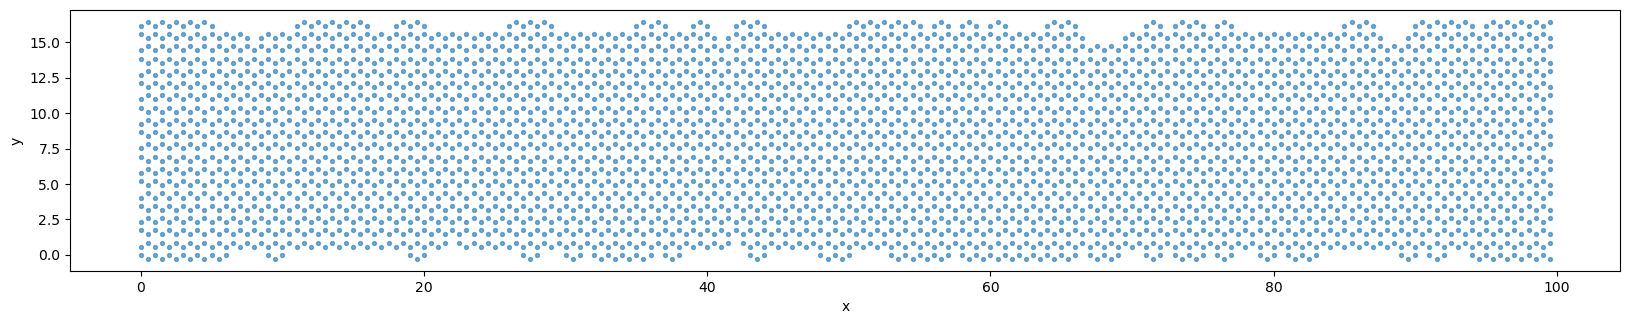

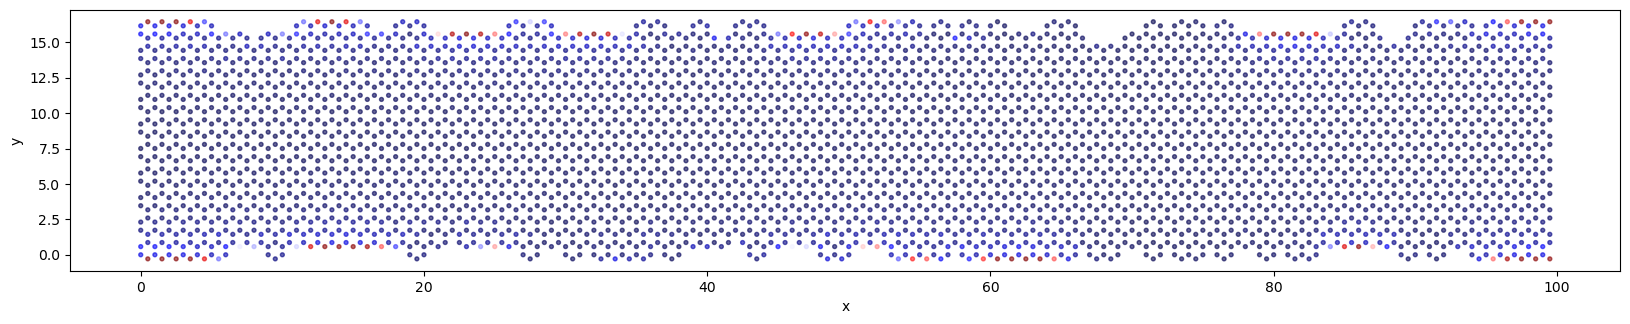

In [454]:

fig, ax = plt.subplots(figsize=(20, 15))

ax.scatter(x1, y1, s=8, cmap="viridis" ,alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")

plt.show()

fig, ax = plt.subplots(figsize=(20, 15))

ax.scatter(x1, y1, s=8,c=m1,cmap="seismic" ,alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")

plt.show()

In [458]:
# folderp=Path("msystems/ZGNR_20_L90_p0.02_n100_20260407_023111")
# filep = folderp / "conf_0001_transport_results.npz"
# datap = np.load(filep)
# # one configuration file structure
# structurep = folderp / "conf_0001_structure_data.npz"
# strucdatap = np.load(structurep, allow_pickle=True)


In [461]:

es = data['energies']
trans = data['trans']
trans_up = data['trans_up']
trans_down = data['trans_down']
T_total = trans_up + trans_down  

###################

esp = datap['energies']
transp = datap['trans']
trans_upp = datap['trans_up']
trans_downp = datap['trans_down']
T_totalp = trans_upp + trans_downp  

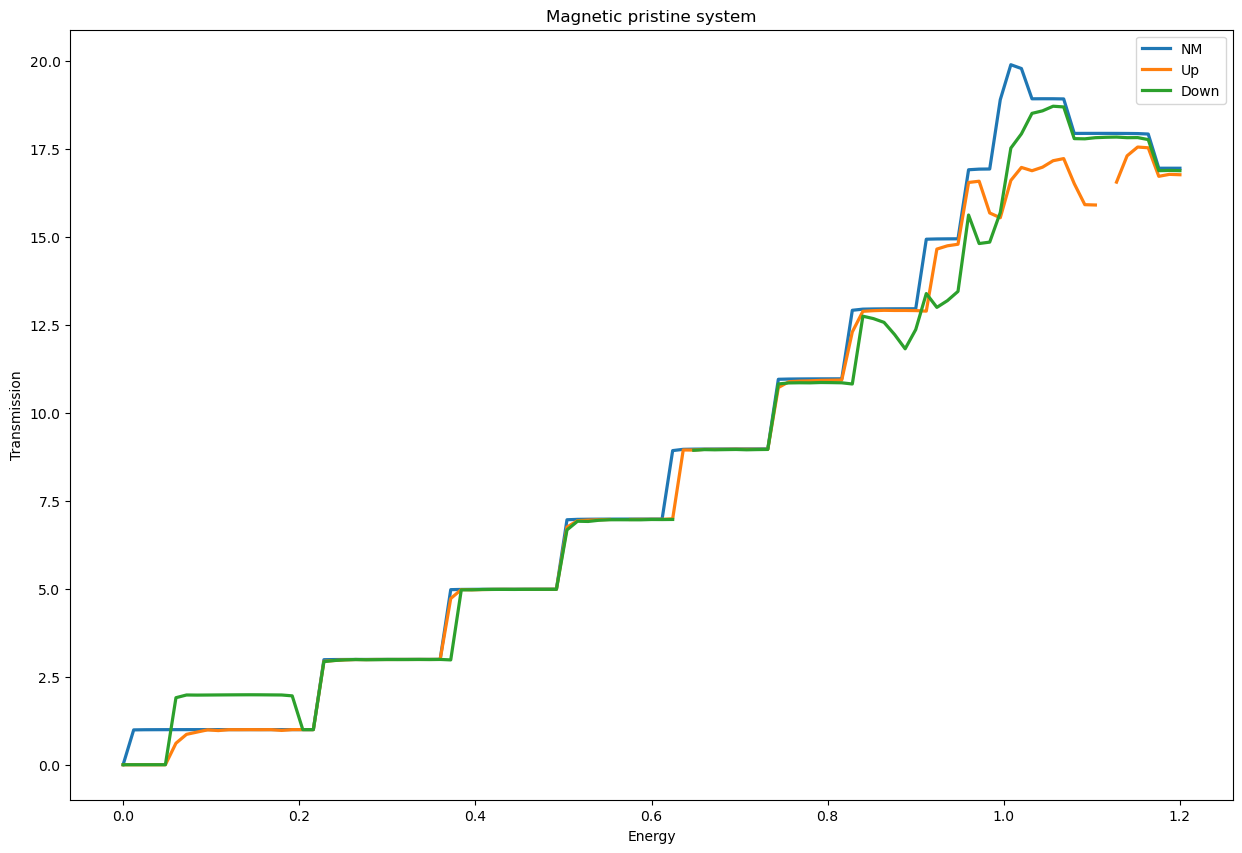

In [487]:
fig, ax = plt.subplots(figsize=(15, 10))
plt.plot(esp, transp,lw=2.3, label='NM')
plt.plot(esp, trans_upp,lw=2.3, label='Up')
plt.plot(esp, trans_downp,lw=2.3, label='Down')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.title('Magnetic pristine system')
plt.legend()
plt.show()


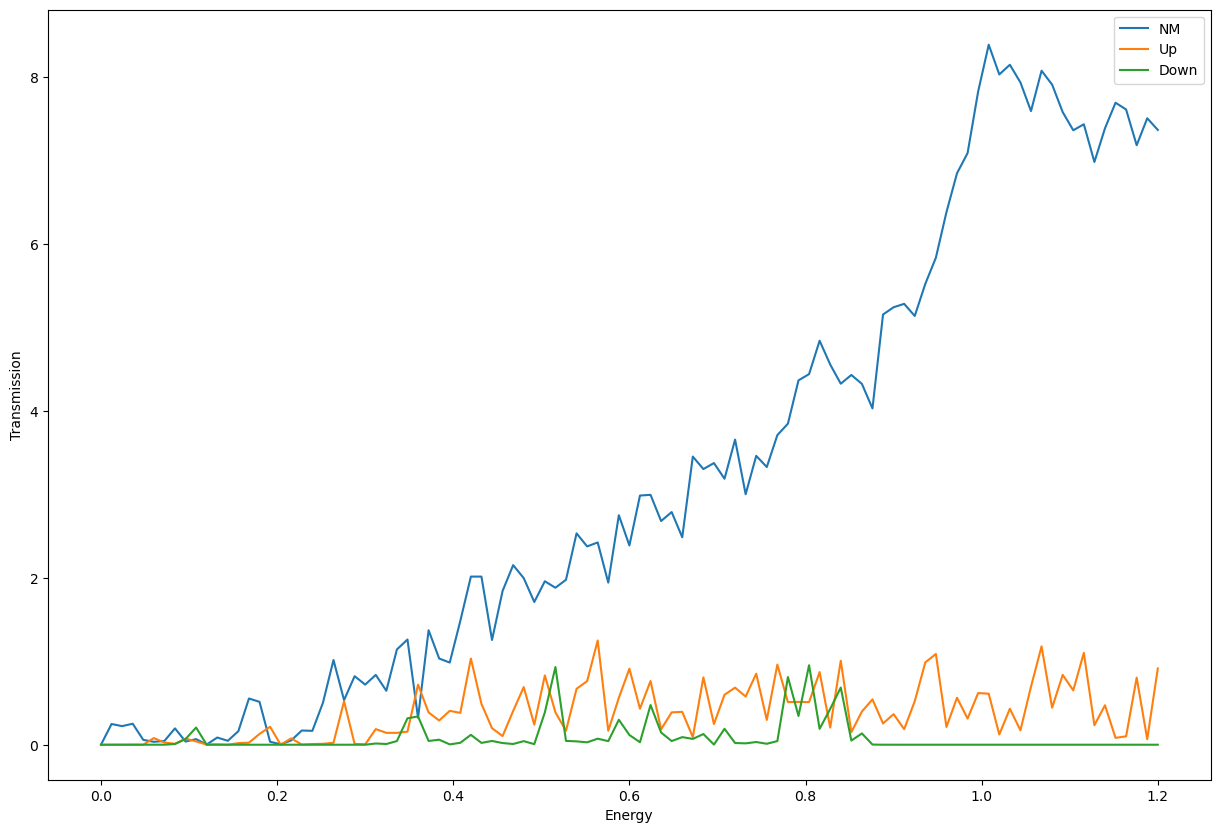

In [465]:
fig, ax = plt.subplots(figsize=(15, 10))
plt.plot(es, trans, label='NM')
plt.plot(es, trans_up, label='Up')
plt.plot(es, trans_down, label='Down')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.legend()
plt.show()

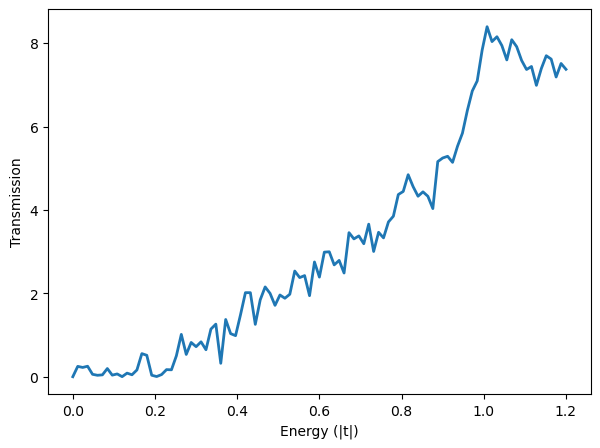

In [467]:

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(es, trans, lw=2) # just printied the first colunm dik what the 2 is check script 
ax.set_xlabel("Energy (|t|)")
ax.set_ylabel("Transmission")
# ax.set_title(f"Transmission – conf {conf_id}")

# ax.grid(True, alpha=0.3)
plt.show()


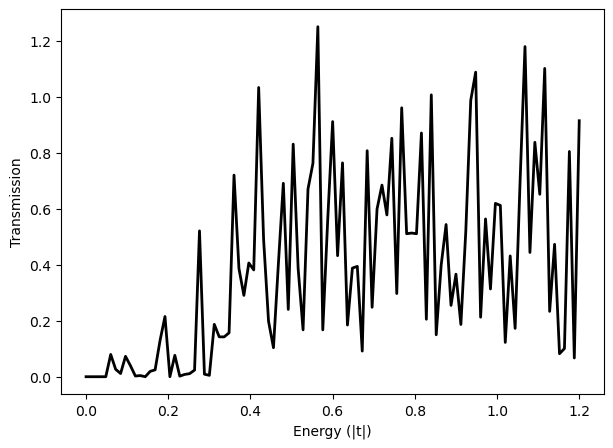

In [316]:

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(es, trans_up, lw=2,c='k') # just printied the first colunm dik what the 2 is check script 
ax.set_xlabel("Energy (|t|)")
ax.set_ylabel("Transmission")
# ax.set_title(f"Transmission – conf {conf_id}")

# ax.grid(True, alpha=0.3)
plt.show()


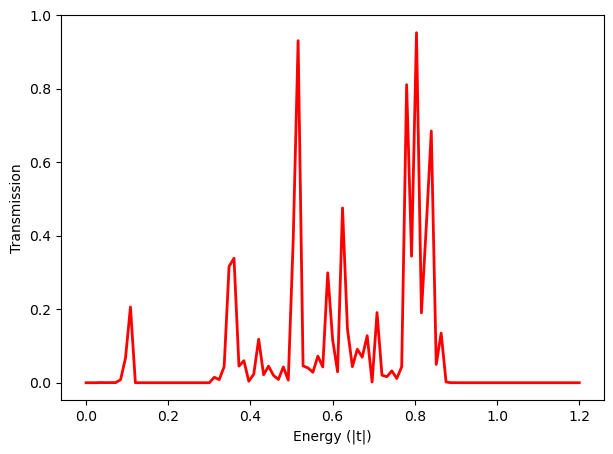

In [318]:

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(es, trans_down, lw=2, c='r') # just printied the first colunm dik what the 2 is check script 
ax.set_xlabel("Energy (|t|)")
ax.set_ylabel("Transmission")
# ax.set_title(f"Transmission – conf {conf_id}")

# ax.grid(True, alpha=0.3)
plt.show()


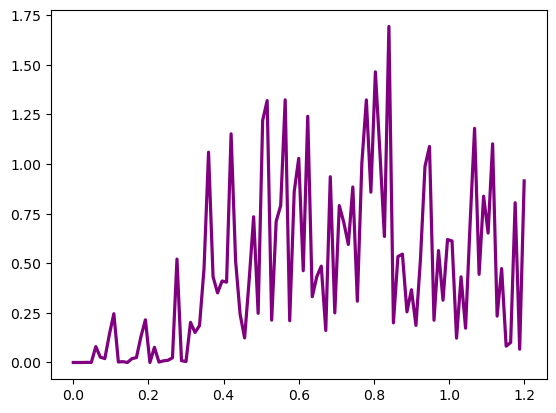

In [320]:
plt.plot(es, T_total,
         color="purple", lw=2.3, label="Config 0001")


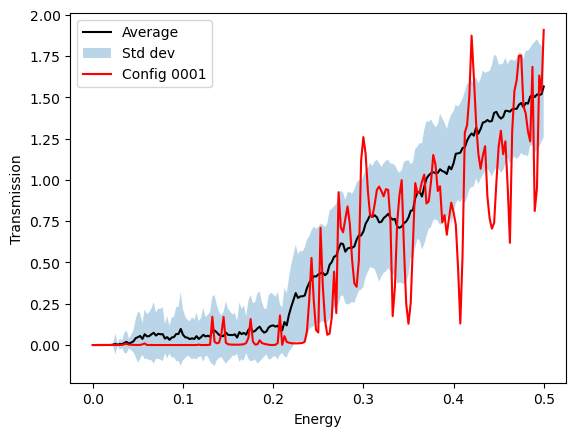

In [111]:
T_all = np.array(Transmissions_combined4)  # shape (n_configs, n_energy)

T_mean = np.mean(T_all, axis=0)
T_std  = np.std(T_all, axis=0)

plt.plot(es, T_mean, color='black', label='Average')

plt.fill_between(es,
                 T_mean - T_std, 
                 T_mean + T_std,
                 alpha=0.3,
                 label='Std dev')

plt.plot(es, T_all[0], color='red', label='Config 0001')

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.legend()

In [ ]:
   # or just use one if identical

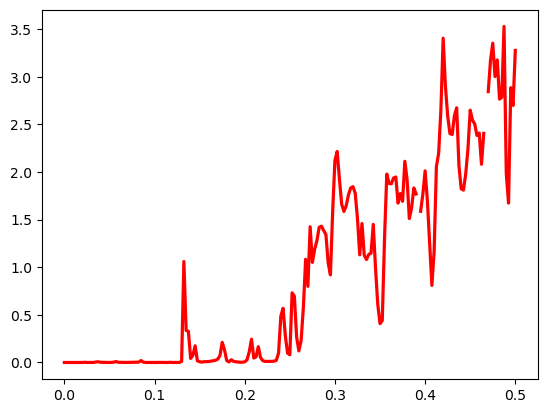

In [117]:
plt.plot(energies, T_total,
         color="red", lw=2.3, label="Config 0001")


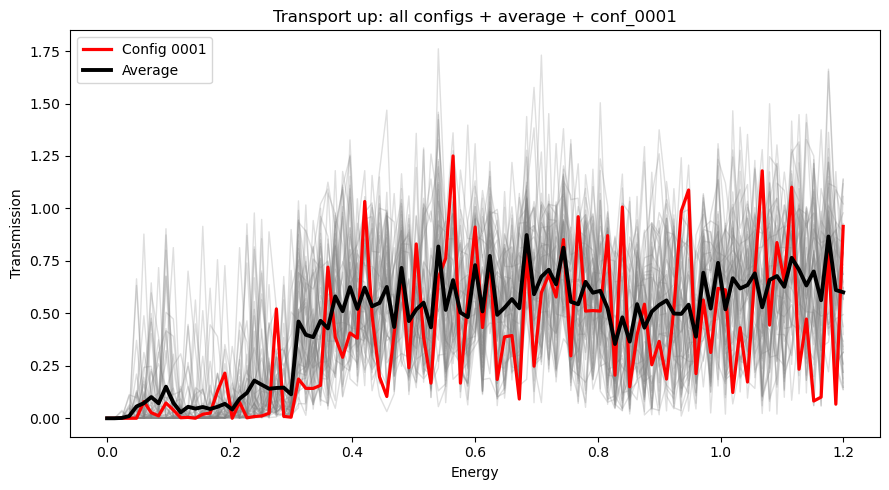

In [479]:
folder = Path("msystems/ZGNR_20_L90_p0.02_n100_20260407_190931")

# ---- load all configs ----
all_files4 = sorted(folder.glob("conf_*_transport_results.npz"))

all_transmissions4 = []
energies = None

for f in all_files4:
    try:   # <<< added this
        data = np.load(f)
        if energies is None:
            energies = data["energies"]        # same for all configs
        all_transmissions4.append(data["trans_up"])
    except Exception as e:   # <<< added this
        print(f"Skipping bad file: {f.name} -> {e}")

Transmissions_combined4 = np.array(all_transmissions4)   # (N_configs, N_energies)

# ---- load config 0001 explicitly ----
file_conf1 = folder / "conf_0001_transport_results.npz"
data1 = np.load(file_conf1)
T_conf1 = data1["trans_up"]

# ---- average ----
T_avg = np.nanmean(Transmissions_combined4, axis=0)

# ---- plot ----
plt.figure(figsize=(9,5))

# all configs: grey transparent
for i in range(Transmissions_combined4.shape[0]):
    plt.plot(energies, Transmissions_combined4[i],
             color="grey", alpha=0.25, lw=1)

# config 0001: red
plt.plot(energies, T_conf1,
         color="red", lw=2.3, label="Config 0001")

# average: black
plt.plot(energies, T_avg,
         color="black", lw=2.8, label="Average")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Transport up: all configs + average + conf_0001")
plt.legend()
plt.tight_layout()
plt.show()

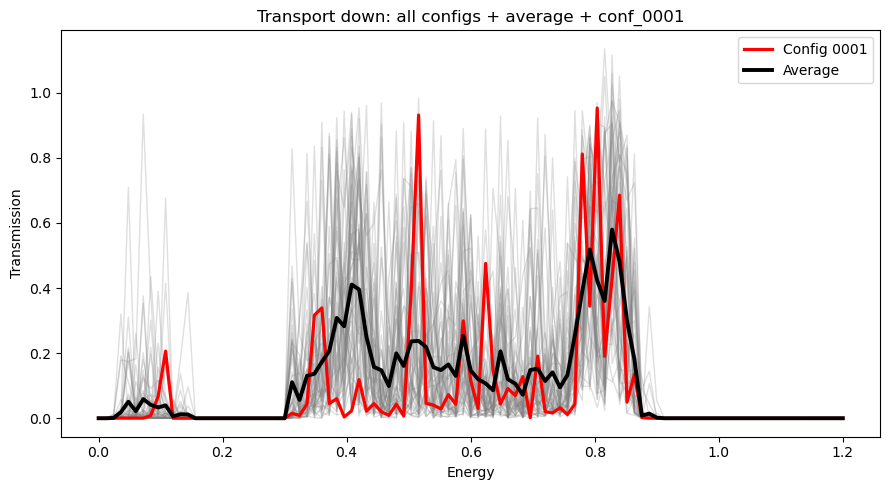

In [501]:
# folder = Path("msystems/ZGNR_20_L90_p0.05_n100_20260330_154808")
folder = Path("msystems/ZGNR_20_L90_p0.02_n100_20260407_190931")
# ---- load all configs ----
all_files4d = sorted(folder.glob("conf_*_transport_results.npz"))

all_transmissions4d = []
energies = None

for f in all_files4d:
    try:   # <<< added this
        data = np.load(f)
        if energies is None:
            energies = data["energies"]        # same for all configs
        all_transmissions4d.append(data["trans_down"])
    except Exception as e:   # <<< added this
        print(f"Skipping bad file: {f.name} -> {e}")

Transmissions_combined4d = np.array(all_transmissions4d)   # (N_configs, N_energies)

# ---- load config 0001 explicitly ----
file_conf1d = folder / "conf_0001_transport_results.npz"
data1d = np.load(file_conf1d)
T_conf1d = data1d["trans_down"]

# ---- average ----
T_avgd = np.nanmean(Transmissions_combined4d, axis=0)

# ---- plot ----
plt.figure(figsize=(9,5))

# all configs: grey transparent
for i in range(Transmissions_combined4d.shape[0]):
    plt.plot(energies, Transmissions_combined4d[i],
             color="grey", alpha=0.25, lw=1)

# config 0001: red
plt.plot(energies, T_conf1d,
         color="red", lw=2.3, label="Config 0001")

# average: black
plt.plot(energies, T_avgd,
         color="black", lw=2.8, label="Average")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Transport down: all configs + average + conf_0001")
plt.legend()
plt.tight_layout()
plt.show()

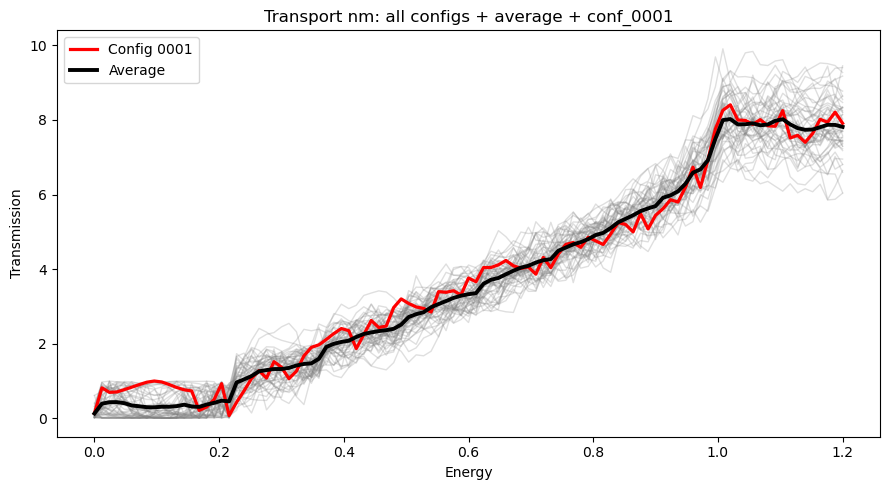

In [473]:
# folder = Path("msystems/ZGNR_20_L90_p0.05_n100_20260330_154808")

# ---- load all configs ----
all_files4nm = sorted(folder.glob("conf_*_transport_results.npz"))

all_transmissions4nm = []
energies = None

for f in all_files4nm:
    try:   # <<< added this
        data = np.load(f)
        if energies is None:
            energies = data["energies"]        # same for all configs
        all_transmissions4nm.append(data["trans"])
    except Exception as e:   # <<< added this
        print(f"Skipping bad file: {f.name} -> {e}")

Transmissions_combined4nm = np.array(all_transmissions4nm)   # (N_configs, N_energies)

# ---- load config 0001 explicitly ----
file_conf1nm = folder / "conf_0001_transport_results.npz"
data1nm = np.load(file_conf1nm)
T_conf1nm = data1nm["trans"]

# ---- average ----
T_avgnm = np.nanmean(Transmissions_combined4nm, axis=0)

# ---- plot ----
plt.figure(figsize=(9,5))

# all configs: grey transparent
for i in range(Transmissions_combined4nm.shape[0]):
    plt.plot(energies, Transmissions_combined4nm[i],
             color="grey", alpha=0.25, lw=1)

# config 0001: red
plt.plot(energies, T_conf1nm,
         color="red", lw=2.3, label="Config 0001")

# average: black
plt.plot(energies, T_avgnm,
         color="black", lw=2.8, label="Average")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Transport nm: all configs + average + conf_0001")
plt.legend()
plt.tight_layout()
plt.show()

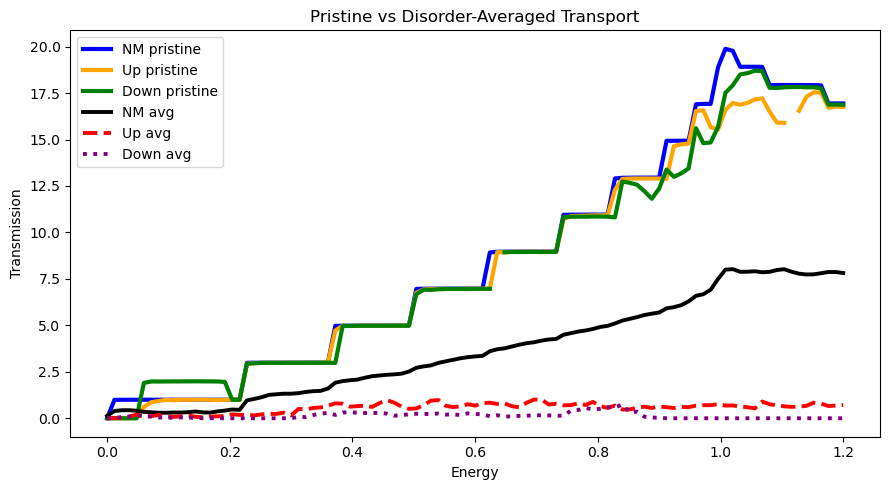

In [441]:
plt.figure(figsize=(9,5))

# ---- Pristine (solid lines) ----
plt.plot(esp, transp, color='blue',  lw=3, label='NM pristine')
plt.plot(esp, trans_upp, color='orange', lw=3, label='Up pristine')
plt.plot(esp, trans_downp, color='green', lw=3, label='Down pristine')

# ---- Disorder averages (BLACK STYLES) ----
plt.plot(es, T_avgnm,   color='black', lw=2.8, linestyle='-',  label='NM avg')
plt.plot(es, T_avg,   color='red', lw=2.8, linestyle='--', label='Up avg')
plt.plot(es, T_avgd, color='purple', lw=2.8, linestyle=':',  label='Down avg')

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Pristine vs Disorder-Averaged Transport")
plt.legend()
plt.tight_layout()
plt.savefig("trasnpposter.png")
plt.show()

In [443]:
out_file = Path("msystems") / "L30-0.05_averaged_transport.npz"
np.savez_compressed(
    out_file,
    energies=energies,
    T_up_avg=T_avg,
    T_down_avg=T_avgd,
    T_nm_avg=T_avgnm,
)

print("Saved averages :", out_file)

Saved averages : msystems/L30-0.05_averaged_transport.npz


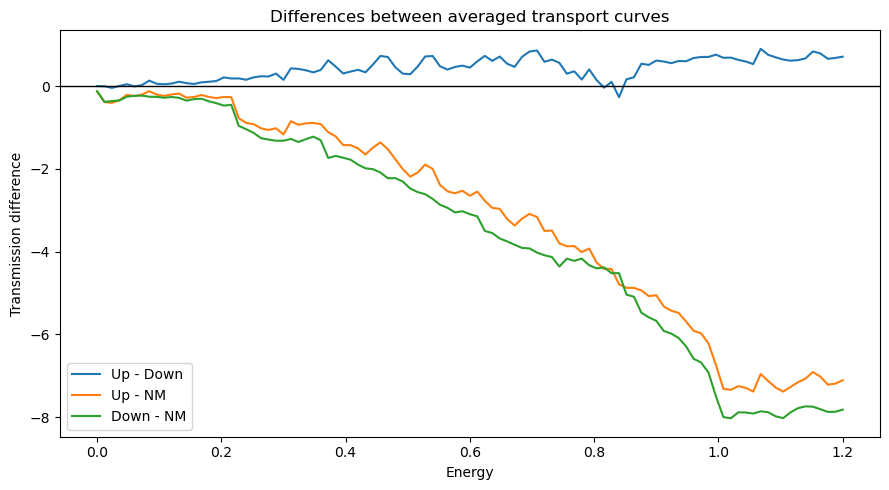

In [445]:
plt.figure(figsize=(9,5))
plt.plot(energies, T_avg - T_avgd, label="Up - Down")
plt.plot(energies, T_avg - T_avgnm, label="Up - NM")
plt.plot(energies, T_avgd - T_avgnm, label="Down - NM")
plt.axhline(0, color="black", lw=1)
plt.xlabel("Energy")
plt.ylabel("Transmission difference")
plt.title("Differences between averaged transport curves")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# out_file = Path("msystems") / "L90-0.02_averaged_transport.npz"
# np.savez_compressed(
#     out_file,
#     energies=energies,
#     T_up_avg=T_avg,
#     T_down_avg=T_avgd,
#     T_nm_avg=T_avgnm,
#     T_up_std=np.nanstd(T_up_all, axis=0),
#     T_down_std=np.nanstd(T_down_all, axis=0),
#     T_nm_std=np.nanstd(T_nm_all, axis=0)
# )

# print("Saved averages + std to:", out_file)